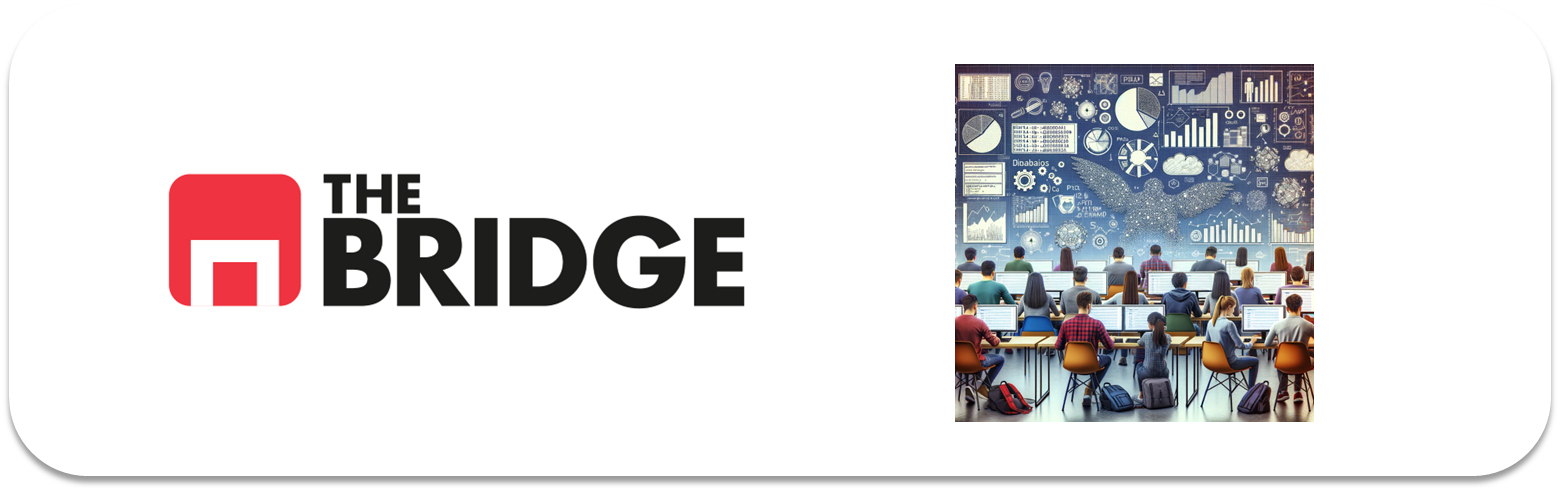

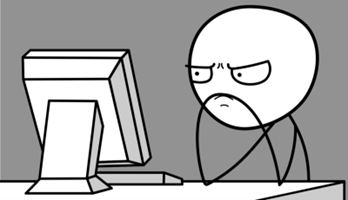

Para ejercitarte y afianzar lo aprendido sobre **Proceso de Datos**, como primera etapa de ML, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

### Ejercicio 1

Carga el dataset de advertising que encontrarás en la carpeta de datos. Muestra su información general. ¿Qué te llama la atención? ¿Tendremos que limpiar alguna variable?

In [2]:
df = pd.read_csv("./data/advertising_ml.csv")
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35 years,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31 years,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26 years,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29 years,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35 años,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [3]:
# Información general: tipos, nulos, cantidad de filas/columnas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   str    
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   str    
 5   City                      1000 non-null   str    
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   str    
 8   Timestamp                 1000 non-null   str    
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(2), str(5)
memory usage: 158.9 KB


In [4]:
# Estadísticas básicas de las columnas numéricas
df.describe()

,Daily Time Spent on Site,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,55000.000080,180.000100,0.481000,0.50000
std,15.853615,13414.634022,43.902339,0.499889,0.50025
min,32.600000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,65470.635000,218.792500,1.000000,1.00000
max,91.430000,79484.800000,269.960000,1.000000,1.00000


### Ejercicio 2

Tenemos que entender el problema antes de seguir. Nos dicen que la compañía "QuickRespond" quiere poder generar un modelo que a partir de datos como los del dataset para poder dirigir mejor su campaña de anuncios. Hablando con ellos llegamos a la conclusión de que queremos un modelo para poder predecir si un usuario pulsará en el link de un anuncio o no. ¿Qué tipo de problemas estamos tratando?¿Y de que tipo de aprendizaje?¿Existe una variable target que puedas identificar rapidamente?

In [5]:
# ¿Qué tipo de problema es?
# → CLASIFICACIÓN: queremos predecir si un usuario hará clic en un anuncio o no.
#   La respuesta es binaria: SÍ (1) o NO (0)

# ¿Tipo de aprendizaje?
# → SUPERVISADO: tenemos datos históricos con la respuesta correcta (el target)
#   El modelo aprende de ejemplos pasados para predecir casos nuevos

# ¿Variable target?
# → La columna que indica si el usuario clickó o no en el anuncio
#   Vamos a identificarla mirando las columnas:
print(df.columns.tolist())

['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Ad Topic Line', 'City', 'Male', 'Country', 'Timestamp', 'Clicked on Ad']


In [6]:
# Una vez identificada visualmente, confirmamos que es binaria (solo 0 y 1)
print(df["Clicked on Ad"].value_counts())

Clicked on Ad
0    500
1    500
Name: count, dtype: int64


### Ejercicio 3

Volvamos ya a los datos. Intenta dar una definicón de cada columna, obten su cardinalidad y en función de esta y del tipo de variable de pandas, clasifícalas en categóricas y numéricas.

In [7]:
# Cardinalidad de cada columna (cuántos valores únicos tiene)
print(df.nunique())

Daily Time Spent on Site     900
Age                           83
Area Income                 1000
Daily Internet Usage         966
Ad Topic Line               1000
City                         969
Male                           2
Country                      237
Timestamp                   1000
Clicked on Ad                  2
dtype: int64


In [8]:
# Tipos de datos de cada columna
print(df.dtypes)

Daily Time Spent on Site    float64
Age                             str
Area Income                 float64
Daily Internet Usage        float64
Ad Topic Line                   str
City                            str
Male                          int64
Country                         str
Timestamp                       str
Clicked on Ad                 int64
dtype: object


In [9]:
# Clasificación manual de columnas
numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categoricas = df.select_dtypes(include=["object"]).columns.tolist()

print("Numéricas:", numericas)
print("Categóricas:", categoricas)

Numéricas: ['Daily Time Spent on Site', 'Area Income', 'Daily Internet Usage', 'Male', 'Clicked on Ad']
Categóricas: ['Age', 'Ad Topic Line', 'City', 'Country', 'Timestamp']


C:\Users\Raquel\AppData\Local\Temp\ipykernel_15000\1538713776.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include=["object"]).columns.tolist()


### Ejercicio 4

Limpia las columnas que necesiten ser limpiadas, no completes nulos (porque asignar valores a nulos sólo puedes hacerlo primero con el train, ya explicaremos con detalle por qué). 

In [11]:
# Timestamp está como texto, la convertimos a formato fecha
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Una vez convertida, podemos extraer info útil de ella
df["Hour"] = df["Timestamp"].dt.hour
df["DayOfWeek"] = df["Timestamp"].dt.dayofweek
df["Month"] = df["Timestamp"].dt.month

# Ya no necesitamos la columna original
df.drop(columns=["Timestamp"], inplace=True)

In [12]:
# Las columnas de texto con cardinalidad muy alta no aportan al modelo
# Ad Topic Line, City y Country tienen demasiados valores únicos
df.drop(columns=["Ad Topic Line", "City", "Country"], inplace=True)

In [13]:
# Verificamos cómo quedó el dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   str    
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Male                      1000 non-null   int64  
 5   Clicked on Ad             1000 non-null   int64  
 6   Hour                      1000 non-null   int32  
 7   DayOfWeek                 1000 non-null   int32  
 8   Month                     1000 non-null   int32  
dtypes: float64(3), int32(3), int64(2), str(1)
memory usage: 66.5 KB


### Ejercicio 5

Divide el datset en train y test, empleando sklearn para ello tal y como hemos hecho en el workout. Usa la regla del 80-20

In [14]:
# Separamos la variable target (lo que queremos predecir) del resto de columnas
X = df.drop(columns=["Clicked on Ad"])  # Features (variables de entrada)
y = df["Clicked on Ad"]                 # Target (lo que queremos predecir)

print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

Tamaño de X: (1000, 8)
Tamaño de y: (1000,)


In [15]:
# Dividimos en train (80%) y test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X,              # Features
    y,              # Target
    test_size=0.2,  # 20% para test
    random_state=42 # Semilla para que la división sea siempre igual
)

print("Tamaño train:", X_train.shape)
print("Tamaño test:", X_test.shape)

Tamaño train: (800, 8)
Tamaño test: (200, 8)


In [16]:
# Comprobamos que la proporción de clics se mantiene en ambos conjuntos
print("Proporción target en train:")
print(y_train.value_counts(normalize=True))

print("\nProporción target en test:")
print(y_test.value_counts(normalize=True))

Proporción target en train:
Clicked on Ad
0    0.51375
1    0.48625
Name: proportion, dtype: float64

Proporción target en test:
Clicked on Ad
1    0.555
0    0.445
Name: proportion, dtype: float64


### Ejercicio 6

Haz un pequeño análisis univariante de las columnas numéricas (muestra sus histogramas)

In [17]:
# Seleccionamos solo las columnas numéricas del train
numericas = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Columnas numéricas:", numericas)

Columnas numéricas: ['Daily Time Spent on Site', 'Area Income', 'Daily Internet Usage', 'Male']


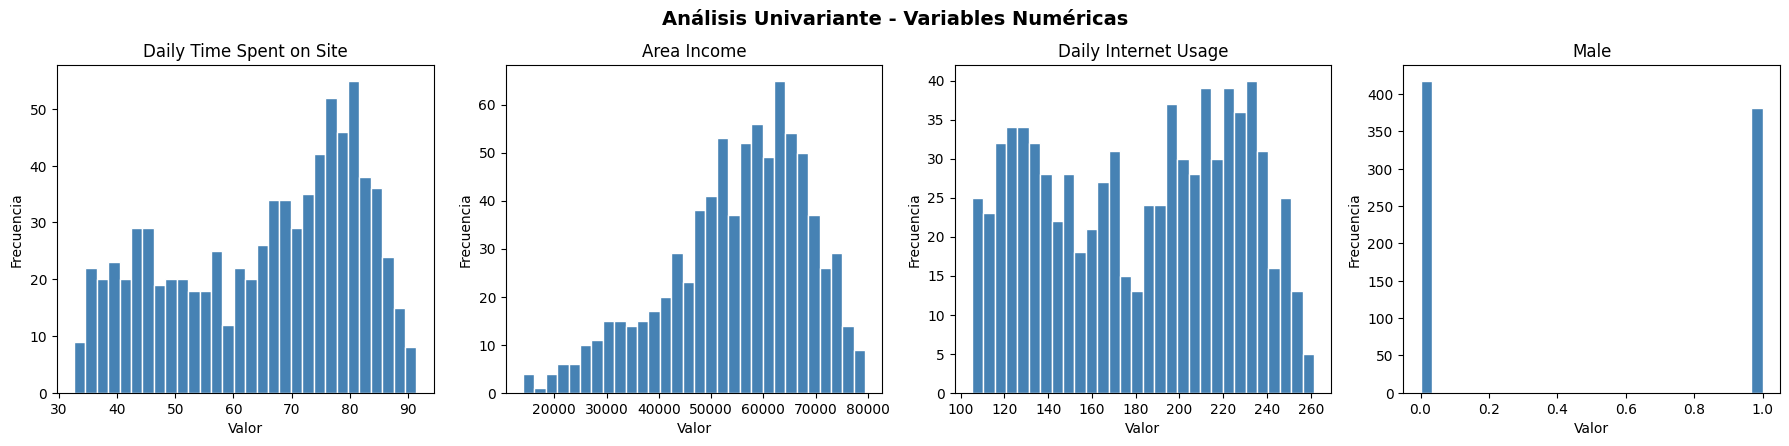

In [18]:
# Pintamos un histograma por cada variable numérica
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 8))
axes = axes.flatten()  # Convertimos la matriz de ejes en una lista plana

for i, col in enumerate(numericas):
    axes[i].hist(X_train[col], bins=30, color="steelblue", edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frecuencia")

# Si sobran ejes vacíos los ocultamos
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Análisis Univariante - Variables Numéricas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Ejercicio 7

Muestra las correlaciones de las variables continuas con un "PairPlot" y emplea como codigo de color la variable target. [Esto es otra forma de hacer un bivariante y un multivariante a la vez]. Para ello como argumento del pairplot de seaborn usa el dataframe de train (no la matriz de correlación)

In [19]:
# Unimos X_train con y_train para poder usar el target como color
train_completo = X_train.copy()
train_completo["Clicked on Ad"] = y_train.values

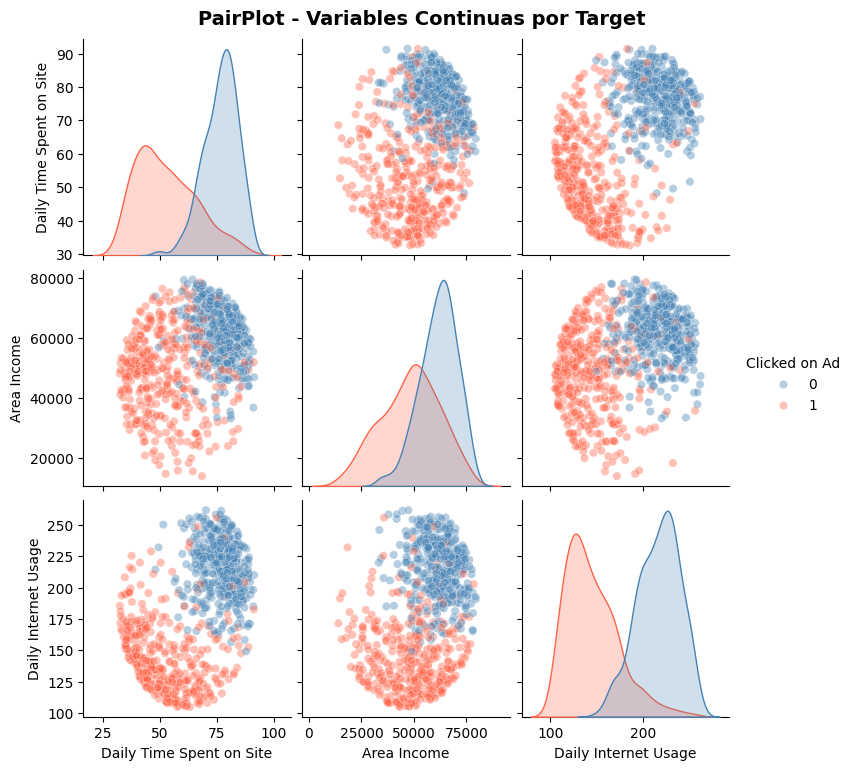

In [20]:
# Seleccionamos solo las columnas continuas + el target
columnas_continuas = [
    "Daily Time Spent on Site",
    "Age",
    "Area Income",
    "Daily Internet Usage",
    "Clicked on Ad"
]

# Pintamos el PairPlot
sns.pairplot(
    train_completo[columnas_continuas],
    hue="Clicked on Ad",        # Color según si hizo clic o no
    palette={0: "steelblue", 1: "tomato"},  # 0 = no clic, 1 = sí clic
    plot_kws={"alpha": 0.4},    # Transparencia para ver mejor la densidad
    diag_kind="kde"             # En la diagonal, curva de densidad en vez de histograma
)

plt.suptitle("PairPlot - Variables Continuas por Target", fontsize=14, fontweight="bold", y=1.02)
plt.show()

### Ejercicio 8

Fijándote en la diagonal principal del gráfico anterior haz una selecció de features:

In [21]:
# Basándonos en la diagonal del PairPlot, seleccionamos las variables
# cuyas curvas azul y roja están más separadas → más poder predictivo

# Las 3 variables continuas con mejor separación son:
features_seleccionadas = [
    "Daily Time Spent on Site",  # Curvas muy separadas
    "Area Income",               # Curvas separadas
    "Daily Internet Usage"       # Curvas muy separadas
]

# Filtramos el train y test con solo esas features
X_train_sel = X_train[features_seleccionadas]
X_test_sel = X_test[features_seleccionadas]

print("Features seleccionadas:", features_seleccionadas)
print("Nuevo tamaño train:", X_train_sel.shape)
print("Nuevo tamaño test:", X_test_sel.shape)

Features seleccionadas: ['Daily Time Spent on Site', 'Area Income', 'Daily Internet Usage']
Nuevo tamaño train: (800, 3)
Nuevo tamaño test: (200, 3)


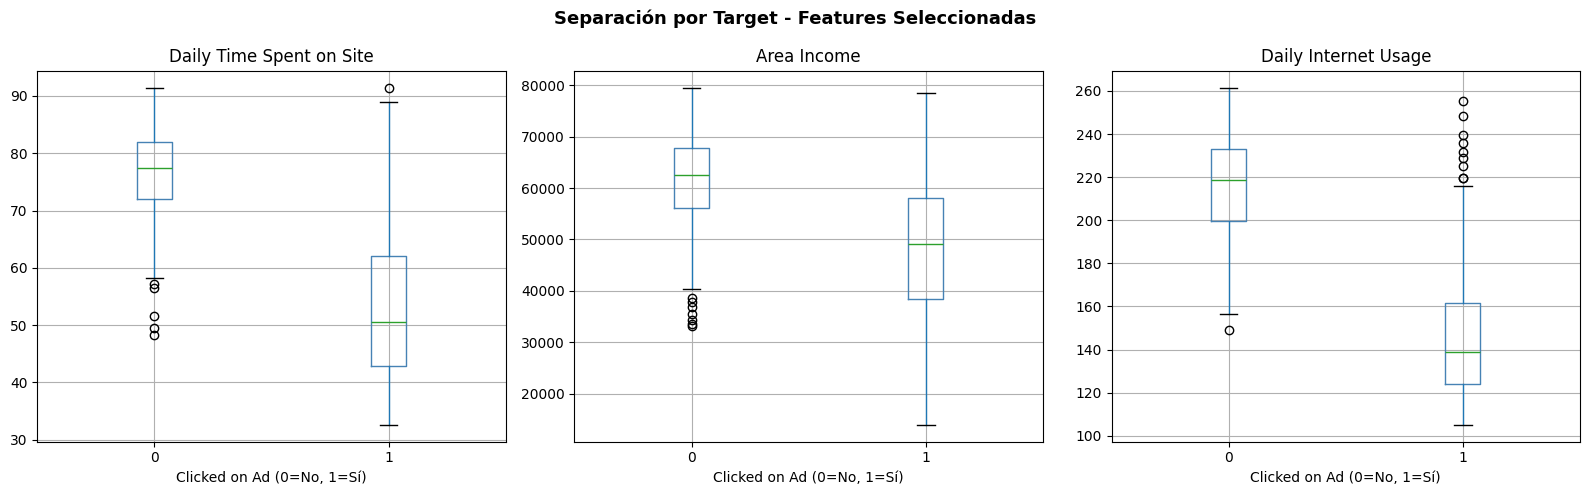

In [22]:
# Podemos confirmar visualmente la separación con un boxplot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(features_seleccionadas):
    train_completo.boxplot(
        column=col,
        by="Clicked on Ad",
        ax=axes[i],
        boxprops=dict(color="steelblue"),
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Clicked on Ad (0=No, 1=Sí)")

plt.suptitle("Separación por Target - Features Seleccionadas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()